<a href="https://colab.research.google.com/github/MMujtabaX/gpt/blob/main/local_llms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/MMujtabaX/local-llms-ollama-gpt4all/blob/main/local_llms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Running Open-Source LLMs Locally: Ollama & GPT4All

Cloud APIs aren't the only way to use large language models. Open-weight models like **Llama 3**, **Gemma 2** and **Qwen 2.5** can run on your own hardware: no API key, no per-token cost, and no data leaving the machine.

This notebook:
1. Sets up **Ollama** (a local model server) inside Google Colab
2. Chats with models, with **streaming** and **multi-turn memory**
3. **Benchmarks** three small models on speed (tokens/second) and answers to the same prompts
4. Gets **structured JSON output** from a local model
5. Runs a larger **Llama 3 8B** model with **GPT4All**

> **Runtime:** use a GPU runtime (Runtime → Change runtime type → **T4 GPU**). Everything also works on CPU, just more slowly.

---
## 1. Setting up Ollama in Colab

Ollama runs as a **background server** on `localhost:11434`, and the Python library talks to it. In Colab we install it, start the server in the background, then download ("pull") models.

In [1]:
!apt-get -qq install -y zstd > /dev/null     # needed by the Ollama installer
!curl -fsSL https://ollama.com/install.sh | sh > /dev/null
!pip install -q ollama

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [2]:
import subprocess, time, requests

# Start the Ollama server in the background
server = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for _ in range(30):                      # wait until the server responds
    try:
        requests.get('http://localhost:11434')
        print("✅ Ollama server is running")
        break
    except requests.ConnectionError:
        time.sleep(1)

✅ Ollama server is running


In [3]:
MODELS = ['llama3.2:1b', 'gemma2:2b', 'qwen2.5:1.5b']   # small models that fit easily on a T4

for m in MODELS:
    print(f"Pulling {m} ...")
    subprocess.run(['ollama', 'pull', m], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
!ollama list

Pulling llama3.2:1b ...
Pulling gemma2:2b ...
Pulling qwen2.5:1.5b ...
NAME            ID              SIZE      MODIFIED       
qwen2.5:1.5b    65ec06548149    986 MB    5 seconds ago     
gemma2:2b       8ccf136fdd52    1.6 GB    13 seconds ago    
llama3.2:1b     baf6a787fdff    1.3 GB    26 seconds ago    


---
## 2. Chatting with a Local Model

### Streaming
Tokens are printed as they're generated, like ChatGPT's typing effect.

In [4]:
import ollama

stream = ollama.chat(
    model='gemma2:2b',
    messages=[{'role': 'user', 'content': 'Why is the sky blue? Answer in 3 sentences.'}],
    stream=True,
)
for chunk in stream:
    print(chunk['message']['content'], end='', flush=True)

The sky appears blue due to a phenomenon called Rayleigh scattering.  Sunlight hitting Earth's atmosphere is scattered by the tiny particles of air, and blue light is scattered more effectively than other colors.  This scattered blue light reaches our eyes from all directions, making the sky appear blue. 


### Multi-turn conversation
LLMs are stateless: "memory" is just sending the **whole conversation history** with every request.

In [5]:
history = [{'role': 'system', 'content': 'You are a concise, friendly tutor. Keep answers under 60 words.'}]

def chat(user_message, model='llama3.2:1b'):
    history.append({'role': 'user', 'content': user_message})
    reply = ollama.chat(model=model, messages=history)['message']['content']
    history.append({'role': 'assistant', 'content': reply})
    print(f"🧑 {user_message}\n🤖 {reply}\n")

chat("What is overfitting in machine learning?")
chat("How can I detect it?")            # 'it' only makes sense because of the history
chat("Give me one way to prevent it.")

🧑 What is overfitting in machine learning?
🤖 Overfitting occurs when a machine learning model is too complex and fits the training data too closely, ignoring general patterns. It's like finding a single hidden object in a crowded room, rather than a whole picture. The model's performance improves initially, but then fails when new, unseen data is introduced.

🧑 How can I detect it?
🤖 To detect overfitting, try:

* Using techniques like regularization (e.g., L1, L2) or early stopping
* Evaluating model performance on unseen data (e.g., k-fold cross-validation)
* Checking model complexity (e.g., number of features, weights)
* Visualizing training and test data to identify patterns
* Monitoring model performance on new, unseen data

These methods can help you identify and adjust for overfitting.

🧑 Give me one way to prevent it.
🤖 Use techniques like **Regularization**, such as L1 or L2 regularization, to limit the model's capacity to fit the training data too closely. This encourages the

---
## 3. Benchmark: Three Small Models

Each model answers the same prompts. Ollama reports exact token counts and timings, so we can measure **generation speed** in tokens per second.

In [6]:
import pandas as pd

prompts = {
    'explain':   "Explain what a neural network is to a 10-year-old in 3 sentences.",
    'reasoning': "A bat and a ball cost $1.10 in total. The bat costs $1.00 more than the ball. How much does the ball cost? Answer briefly.",
    'code':      "Write a Python function that checks whether a string is a palindrome. Code only.",
}

rows, answers = [], {}
for m in MODELS:
    ollama.generate(model=m, prompt='hi', options={'num_predict': 1})   # warm-up: load model into memory
    for name, prompt in prompts.items():
        r = ollama.generate(model=m, prompt=prompt, options={'temperature': 0, 'num_predict': 300})
        tokens = r['eval_count']
        seconds = r['eval_duration'] / 1e9
        rows.append({'model': m, 'prompt': name, 'output tokens': tokens,
                     'tokens/sec': round(tokens / seconds, 1),
                     'total time (s)': round(r['total_duration'] / 1e9, 2)})
        answers[(m, name)] = r['response'].strip()

bench = pd.DataFrame(rows)
bench.pivot(index='model', columns='prompt', values='tokens/sec')

prompt,code,explain,reasoning
model,,,
gemma2:2b,10.3,10.9,11.5
llama3.2:1b,15.8,15.1,15.0
qwen2.5:1.5b,18.0,18.7,20.1


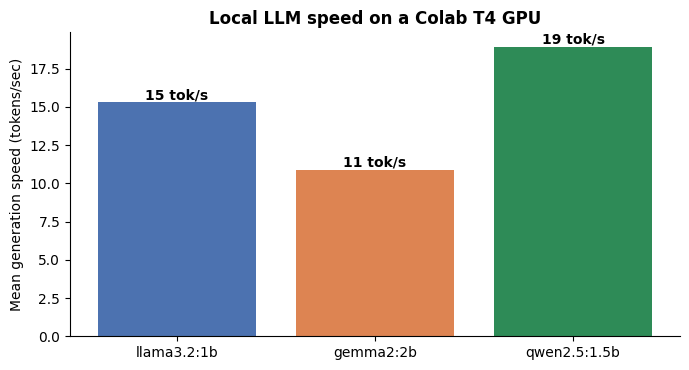

In [7]:
import matplotlib.pyplot as plt

speed = bench.groupby('model')['tokens/sec'].mean().reindex(MODELS)
plt.figure(figsize=(7, 3.8))
bars = plt.bar(speed.index, speed.values, color=['#4C72B0', '#DD8452', '#2E8B57'])
plt.bar_label(bars, fmt='%.0f tok/s', fontweight='bold')
plt.ylabel('Mean generation speed (tokens/sec)')
plt.title('Local LLM speed on a Colab T4 GPU', fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Comparing the answers
The reasoning prompt is a classic trick question: the intuitive answer is **$0.10**, but the correct answer is **$0.05**.

In [8]:
for name in prompts:
    print("=" * 90)
    print(f"PROMPT [{name}]: {prompts[name]}")
    for m in MODELS:
        print(f"\n--- {m} ---\n{answers[(m, name)][:600]}")

PROMPT [explain]: Explain what a neural network is to a 10-year-old in 3 sentences.

--- llama3.2:1b ---
A neural network is like a super smart computer that can learn and get better at doing things on its own, kind of like how you learn new things in school. It's made up of many tiny computers that work together to figure out patterns and make decisions, and it can even recognize pictures and sounds that it hasn't seen before. Imagine you're trying to teach a robot to recognize different types of animals - the neural network would be like a teacher that helps the robot learn by showing it lots of pictures of different animals and then asking it to identify them.

--- gemma2:2b ---
Imagine a bunch of tiny brain cells connected together, like a big puzzle.  Each connection has a little bit of "strength" that helps the brain cells learn from the information they get.  The more information the brain cells see, the better they get at solving problems and making predictions!

--- qwen2.5:1.

---
## 4. Structured Output: JSON from a Local Model

For applications, free text isn't enough: you need data your code can parse. Ollama's `format='json'` constrains the model to output valid JSON.

In [9]:
import json

review = "The battery life is amazing and the screen is gorgeous, but it overheats when gaming and the price is too high."

response = ollama.chat(
    model='qwen2.5:1.5b',
    format='json',
    options={'temperature': 0},
    messages=[{'role': 'user', 'content':
        'Extract from this product review a JSON object with keys "sentiment" (positive/negative/mixed), '
        '"pros" (list of strings) and "cons" (list of strings).\n\nReview: ' + review}],
)
data = json.loads(response['message']['content'])
print(json.dumps(data, indent=2))

{
  "sentiment": "mixed",
  "pros": [
    "battery life is amazing",
    "screen is gorgeous"
  ],
  "cons": [
    "overheats when gaming",
    "price is too high"
  ]
}


---
## 5. A Bigger Model with GPT4All: Llama 3 8B

**GPT4All** runs quantized models directly inside Python, with no separate server. **Q4_0** quantization stores weights in 4 bits, shrinking Llama 3 8B from about 16 GB to **4.66 GB** so it fits on consumer hardware.

In [10]:
!pip install -q gpt4all

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 10.4 MB/s eta 0:00:00


In [12]:
from gpt4all import GPT4All

start = time.time()
try:
    model = GPT4All("Meta-Llama-3-8B-Instruct.Q4_0.gguf", device='cuda')
    print("Running on GPU")
except Exception:
    model = GPT4All("Meta-Llama-3-8B-Instruct.Q4_0.gguf", device='cpu')   # same model, runs on CPU
    print("CUDA backend not available, running on CPU")
print(f"Model loaded in {time.time() - start:.0f}s")

CUDA backend not available, running on CPU
Model loaded in 1s


In [13]:
with model.chat_session():
    start = time.time()
    answer = model.generate("Write a short summary of the most important AI use cases in 2024.", max_tokens=200)
    elapsed = time.time() - start
print(answer)
print(f"\n⏱️ {elapsed:.1f}s for up to 200 tokens")

Based on current trends and developments, here are some of the most promising AI use cases expected to gain traction in 2024:

1. **Autonomous Vehicles**: Level 3-5 autonomous vehicles will become more prevalent, with companies like Waymo, Tesla, and Cruise continuing to refine their self-driving technologies for passenger and goods transportation.
2. **Healthcare Analytics**: AI-powered diagnostic tools will improve patient outcomes by analyzing medical images (e.g., MRI, CT scans), genomic data, and electronic health records to detect diseases earlier and personalize treatment plans.
3. **Customer Service Chatbots**: Conversational AI will become the norm in customer service, enabling businesses to provide 24/7 support through messaging platforms like WhatsApp, Facebook Messenger, and Slack.
4. **Supply Chain Optimization**: AI-driven logistics solutions will streamline inventory management, route optimization, and predictive maintenance for industries like e-commerce, manufacturing,

In [14]:
with model.chat_session():
    print(model.generate("Tell me a short joke about programmers.", max_tokens=64))

Why do programmers prefer dark mode?

Because light attracts bugs!


---
## Summary

| | Ollama | GPT4All |
|--|--------|---------|
| How it runs | Background server + REST API | Directly inside Python |
| Model management | `ollama pull <model>` | Downloads by filename |
| Best for | Apps and services, several models, JSON mode | Simple scripts, desktop use |

**Local LLMs vs cloud APIs:**
- ✅ Private: data never leaves the machine
- ✅ No per-token cost or rate limits, and works offline
- ⚠️ Smaller models are noticeably weaker at reasoning (see the bat-and-ball test)
- ⚠️ You provide the hardware: speed depends on the GPU and the model size